
# 📊 KIKO Platform — Model Evaluation Notebook

This notebook evaluates the **KIKO** platform using **FastAPI** endpoints over the **EducTUM** dataset.
It measures:
- **Retrieval (RAG):** Recall_k, MRR, nDCG, Citation Rate, Attribution Match  
- **Generation (Chat):** ROUGE-L, BLEU, BERTScore  
- **Answer Grading:** Accuracy, MAE, Within-1, Quadratic-weighted Cohen’s κ

In [17]:
# ========= Import required Packages =========
import os, json, math, time, requests, mlflow, subprocess
import numpy as np
import pandas as pd
from typing import List, Dict, Any
from dataclasses import dataclass

from sklearn.metrics import accuracy_score, confusion_matrix, cohen_kappa_score, mean_absolute_error
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from jiwer import wer, cer

import evaluate  # HF metrics
import matplotlib.pyplot as plt

from jinja2 import Template
from dotenv import load_dotenv
from pathlib import Path
load_dotenv()

True

In [18]:
# ========= Configuration =========
DOCKER_DB_SERVICE_NAME = os.getenv("DOCKER_DB_SERVICE_NAME")
DATABASE_PORT = os.getenv("POSTGRES_DATABASE_PORT")
POSTGRES_DB = os.getenv("POSTGRES_DB")
POSTGRES_USER = os.getenv("POSTGRES_USER")
POSTGRES_PASSWORD = os.getenv("POSTGRES_PASSWORD")
# print(f"\n Docker DB Servicxe name:{DOCKER_DB_SERVICE_NAME} \n DB Port:{DATABASE_PORT} \n Database Name:{POSTGRES_DB} \n User Name:{POSTGRES_USER} \n PWD: {POSTGRES_PASSWORD} \n")

BACKEND_API_URL = "http://localhost:8004"
USERNAME = os.getenv("KIKO_USER", "instructor1@tum.de")
PASSWORD = os.getenv("KIKO_PASS", "Instructor@2025")
# print(f"\n Backend API URL:{BACKEND_API_URL} \n login User Name:{USERNAME} \n login PWD: {PASSWORD} \n")

pwd = os.getcwd()
# print(pwd)

In [19]:
LLM_MODEL_NAME = "llama3:70b-instruct"
EMBEDDING_MODEL_NAME = "nomic-embed-text:latest"
INFERENCE_MODEL_NAME = "deepseek-r1:32b"
LANG_DEFAULT = "de"
TOP_K = 5
EVAL_CSV_PATH = "assets/eductum-eval.csv"

In [20]:
# Local folder (default):
mlflow.set_tracking_uri("file:./mlruns")

# Name your experiment
mlflow.set_experiment("KIKO-Evaluation")

<Experiment: artifact_location='file:///mnt/data3/develop-project/kiko-platform/notebooks/mlruns/780707568230540418', creation_time=1759150560709, experiment_id='780707568230540418', last_update_time=1759150560709, lifecycle_stage='active', name='KIKO-Evaluation', tags={}>

In [21]:
def login(username: str, password: str) -> Dict[str, str]:
    """ Authenticate and return Authorization header."""
    url = f"{BACKEND_API_URL}/api/authentication/authenticate"
    
    payload = {
        "email": username, 
        "password": password
    }
    
    r = requests.post(url, json= payload, headers={"Content-Type": "application/json"})
    r.raise_for_status()
    data = r.json()    
    token = data.get("access_token")
    if not token:
        raise RuntimeError("No token in auth response.")
    return {"Authorization": f"Bearer {token}"}

In [22]:
HDRS = login(USERNAME, PASSWORD)
HDRS_JSON = {**HDRS, "Content-Type": "application/json"}
# print(f"Token:{HDRS_JSON}")

In [23]:
def call_chat(question: str) -> Dict[str, Any]:
    """ Call chatbot endpoint. Expecting answer + citations + optionally retrieved chunks."""
    url = f"{BACKEND_API_URL}/api/chatbot/query"
    
    payload = {
        "query": question,
        "llm_model": LLM_MODEL_NAME,
        "embedding_model": EMBEDDING_MODEL_NAME,
        "answer_language": LANG_DEFAULT
    }
    r = requests.post(url, headers=HDRS_JSON, json=payload)
    r.raise_for_status()
    data = r.json().get("data", {})
    return data 

In [24]:
def call_grader(question: str, user_answer: str, reference_answer: str = None) -> Dict[str, Any]:
    """ Call grading endpoint. Expecting at least a 'grade' and optionally 'feedback'."""
    url = f"{BACKEND_API_URL}/api/course_creator/answer_grading"
    payload = {
        "question": question,
        "reference_answer": reference_answer,
        "user_answer": user_answer,
        "reasoning_model_name":INFERENCE_MODEL_NAME
    }
    r = requests.post(url, headers=HDRS_JSON, json=payload)
    r.raise_for_status()
    data = r.json()
    # print(f"Results:{data}")
    return data

In [25]:
df = pd.read_csv(EVAL_CSV_PATH)
expected_cols = {"file_name","question","reference_answer","user_answer","human_grade"}
missing = expected_cols - set(df.columns)
if missing:
    print("⚠️ Missing columns in CSV:", missing)
else:
    print("✅ CSV loaded:", df.shape)
df.head()

✅ CSV loaded: (20, 5)


,file_name,question,reference_answer,user_answer,human_grade
0,2025-04-14-1.pdf,Was ist segmentiertes Gamma-Scanning (SGS)?,"SGS ist ein zerstörungsfreies Messverfahren, b...","Man scannt das Fass mit einem Detektor, um die...",2
1,2025-04-14-1.pdf,Wofür wird SGS in der Stilllegung typischerwei...,"Zur Charakterisierung von Abfallgebinden, z. B...",Hauptsächlich für die Charakterisierung von Fä...,2
2,2025-04-14-1.pdf,Nenne zwei Vorteile des SGS gegenüber rein dok...,SGS liefert unabhängige Messdaten und ermöglic...,Es ist schneller und spart Papierkram.,4
3,2025-04-14-1.pdf,Was bedeutet Genehmigungs- und Anzeigepflicht ...,Bestimmte Rückbautätigkeiten dürfen nur mit be...,"Man muss die Behörde fragen oder informieren, ...",3
4,2025-04-14-1.pdf,Erklären Sie den Aufbau eines typischen Gammas...,Ein Gammaspektrum zeigt die Z�hlrate in Abh�ng...,"Ein Gammaspektrum hat verschiedene Ausschl�ge,...",5


## HuggingFace evaluate metrics

In [26]:
rouge = evaluate.load("rouge")
bleu  = evaluate.load("bleu")
bertscore = evaluate.load("bertscore")  # requires internet once to fetch model weights; cached afterwards

In [27]:
def is_relevant(item: Any, gold_doc_id: str) -> int:
    """Return 1 if the citation/retrieved item refers to the gold doc id; else 0.
    This function tries to be permissive: it stringifies the item and searches for doc_id.
    You can customize to exact matching (e.g., item['doc_id'] == gold_doc_id)."""
    try:
        s = json.dumps(item, ensure_ascii=False)
    except Exception:
        s = str(item)
    return int(gold_doc_id in s)

def recall_at_k(items: List[Any], gold_doc_id: str) -> int:
    return 1 if any(is_relevant(it, gold_doc_id) for it in items) else 0

def mean_reciprocal_rank(items: List[Any], gold_doc_id: str) -> float:
    for idx, it in enumerate(items, start=1):
        if is_relevant(it, gold_doc_id):
            return 1.0 / idx
    return 0.0

def ndcg_at_k(items: List[Any], gold_doc_id: str) -> float:
    """Binary relevance nDCG where rel=1 if matches gold doc, 0 otherwise."""
    gains = []
    for i, it in enumerate(items, start=1):
        rel = is_relevant(it, gold_doc_id)
        # DCG with log2 discount
        gains.append(rel / math.log2(i + 1))
    dcg = sum(gains)
    # IDCG = best possible ordering: first relevant gets the top slot
    # If there is at least one relevant item, IDCG is 1/log2(2) = 1.0
    idcg = 1.0 if any(is_relevant(it, gold_doc_id) for it in items) else 0.0
    return (dcg / idcg) if idcg > 0 else 0.0

In [28]:
def attribution_match(answer_text: str, cited_texts: List[str]) -> float:
    """Compute cosine similarity between answer and concatenated cited texts via TF-IDF.
    If no cited_texts, return NaN. If you can return full chunk texts from API, use them here.
    You can replace TF-IDF with sentence-transformers if available."""
    if not cited_texts:
        return float("nan")
    corpus = [answer_text, " ".join(cited_texts)]
    vec = TfidfVectorizer().fit_transform(corpus)
    sim = cosine_similarity(vec[0], vec[1])[0,0]
    return float(sim)

In [29]:
def safe_bleu_score(pred: str, ref: str) -> float:
    pred = (pred or "").strip()
    ref  = (ref or "").strip()
    # Handle empties explicitly to avoid ZeroDivisionError
    if not pred and not ref:
        return 1.0  # identical emptiness → perfect match by convention
    if not pred or not ref:
        return 0.0  # one is empty → no overlap

    try:
        out = bleu.compute(
            predictions=[pred],
            references=[[ref]],  # <- list of list
            smooth=True          # <- enable smoothing to avoid zero-precision blowups
        )
        return float(out["bleu"])
    except ZeroDivisionError:
        return 0.0

## Evaluate Chat Assistant response

In [30]:
chat_rows = []
for i, row in df.iterrows():
    q = row.get("question","")
    ref = row.get("reference_answer","")
    gold_doc = str(row.get("file_name",""))
    if not q or not gold_doc:
        continue

    out = call_chat(q)
    pred = out.get("answer")
    # print(f"{i} -> Generated Answers:{pred}")
    citations = out.get("source_docs")
    # print(f"{i} -> Generated Citations:{citations}")
    
    ### Generation metrics ###
    
    # ROUGE-L → Measures the longest common subsequence between generated and reference answer.
    # Good for factual overlap (did it cover the same content?).
    r_ = rouge.compute(predictions=[pred], references=[ref])
    rouge_l = r_["rougeL"]

    # BLEU → Measures n-gram overlap (word sequences).
    # Common in translation tasks. Caution: BLEU can be misleading for short, free-form answers (e.g., “Yes” vs. “Correct”).
    # Use mostly for structured or longer answers.
    bleu_s = safe_bleu_score(pred, ref) # bleu.compute(predictions=[pred], references=[[ref]])

    # BERTScore → Embedding-based semantic similarity. Captures meaning similarity beyond word overlap.
    # If the assistant says “The reactor vessel is dismantled in phases” vs. reference “Decommissioning happens step-by-step” → BLEU may be low, but BERTScore will be high.
    # Best for free-form natural answers.
    bs_ = bertscore.compute(predictions=[pred], references=[ref], lang=LANG_DEFAULT)
    bs_f1 = bs_["f1"][0]
    
    ### Retrieval metrics ###
    
    # Recall_k → % of times the correct document/section is present in the top-k retrieved chunks.
    # High Recall_5 (e.g., 90%) means relevant info usually appears in the retrieved context.
    # Low recall → your embeddings or retriever aren’t surfacing the right knowledge.
    rec = recall_at_k(citations, gold_doc)

    # MRR (Mean Reciprocal Rank) → Measures how high up the correct chunk appears.
    # If the correct passage is usually ranked 1st, MRR ≈ 1.0.
    # If it’s often 3rd, MRR ≈ 0.33.
    # Good for showing not just if the chunk is retrieved, but how quickly it appears.
    mrr = mean_reciprocal_rank(citations, gold_doc)

    # nDCG (Normalized Discounted Cumulative Gain) → Weighs relevance + position in ranking.
    # High nDCG → correct chunks consistently ranked near the top.
    # Better than recall when you want to reward “getting the best chunk first”.
    ndcg = ndcg_at_k(citations, gold_doc)

    # Attribution Match → Do the cited chunks actually match the content of the answer?
    # Example: Model cites a chunk, but the chunk is irrelevant → citation without attribution.
    # High attribution match means the assistant isn’t just citing randomly but grounding its reasoning correctly.
    cited_texts = []
    for it in citations:
        if isinstance(it, dict):
            if "retrieved_chunks" in it:
                cited_texts.append(it["retrieved_chunks"])

    # print(f"citest text:{cited_texts} \n")
    attr = attribution_match(pred, cited_texts)

    chat_rows.append({
        "idx": i,
        "doc_name": gold_doc,
        "question": q,
        "pred": pred,
        "ref": ref,
        "rougeL": rouge_l,
        "bleu": bleu_s,
        "bertscore_f1": float(bs_f1),
        "citation_rate": int(len(citations) > 0),
        "recall_k": rec,
        "mrr": mrr,
        "ndcg": ndcg,
        "attribution_match": attr
    })

eval_chat = pd.DataFrame(chat_rows)
print("✅ Chat evaluated:", eval_chat.shape)
eval_chat

✅ Chat evaluated: (20, 13)


,idx,doc_name,question,pred,ref,rougeL,bleu,bertscore_f1,citation_rate,recall_k,mrr,ndcg,attribution_match
0,0,2025-04-14-1.pdf,Was ist segmentiertes Gamma-Scanning (SGS)?,Im Kontext der Kontaminationskontrolle wird SG...,"SGS ist ein zerstörungsfreies Messverfahren, b...",0.120000,0.035816,0.681522,1,0,0.0,0.0,0.233180
1,1,2025-04-14-1.pdf,Wofür wird SGS in der Stilllegung typischerwei...,Die Beförderungsgenehmigung muss nicht mitgefü...,"Zur Charakterisierung von Abfallgebinden, z. B...",0.125000,0.036974,0.631166,1,0,0.0,0.0,0.310616
2,2,2025-04-14-1.pdf,Nenne zwei Vorteile des SGS gegenüber rein dok...,Die Gefahrzettel/Gefahrenkennzeichen für radio...,SGS liefert unabhängige Messdaten und ermöglic...,0.059701,0.036748,0.627141,1,0,0.0,0.0,0.357175
3,3,2025-04-14-1.pdf,Was bedeutet Genehmigungs- und Anzeigepflicht ...,Die Beförderungsgenehmigung muss nicht mitgefü...,Bestimmte Rückbautätigkeiten dürfen nur mit be...,0.063492,0.016409,0.659989,1,0,0.0,0.0,0.406877
4,4,2025-04-14-1.pdf,Erklären Sie den Aufbau eines typischen Gammas...,Die Peaks sind nicht genauso hoch wie in Fall ...,Ein Gammaspektrum zeigt die Z�hlrate in Abh�ng...,0.133333,0.025072,0.622638,1,0,0.0,0.0,0.472946
5,5,2025-04-14-1.pdf,Erklären Sie den Aufbau eines typischen Gammas...,"Die Peaks sind genauso hoch wie in Fall 3, da ...",Ein Gammaspektrum zeigt die Z�hlrate in Abh�ng...,0.133333,0.029598,0.632603,1,0,0.0,0.0,0.473503
6,6,2025-04-14-1.pdf,Wozu dient die Segmentierung in der nuklearen ...,Die Segmentierung dient zur Ortsverteilung von...,Segmentierung bedeutet die Abgrenzung von Regi...,0.134615,0.066592,0.721448,1,0,0.0,0.0,0.360291
7,7,2025-04-14-1.pdf,Wozu dient die Segmentierung in der nuklearen ...,Die Segmentierung dient zur räumlichen Auflösu...,Segmentierung bedeutet die Abgrenzung von Regi...,0.119658,0.024245,0.700169,1,0,0.0,0.0,0.322715
8,8,Grundlagen-des-Strahlenschutzes.pdf,Nennen Sie die drei Grundprinzipien des Strahl...,Im Umgang mit einem Strahler müssen bestimmte ...,Die drei Grundprinzipien sind: Rechtfertigung:...,0.119658,0.036313,0.650638,1,0,0.0,0.0,0.351609
9,9,Grundlagen-des-Strahlenschutzes.pdf,Nennen Sie die drei Grundprinzipien des Strahl...,Im Umgang mit einem Strahler müssen bestimmte ...,Die drei Grundprinzipien sind: Rechtfertigung:...,0.120690,0.035856,0.649244,1,0,0.0,0.0,0.337690


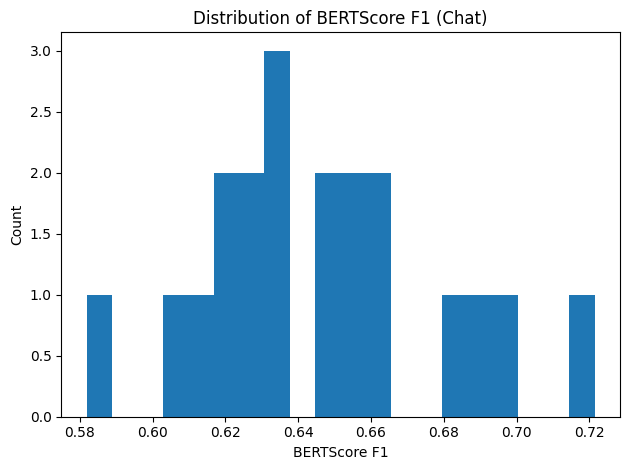

In [31]:
# Distribution of BERTScore
if len(eval_chat):
    fig = plt.figure()
    plt.hist(eval_chat["bertscore_f1"].dropna(), bins=20)
    plt.title("Distribution of BERTScore F1 (Chat)")
    plt.xlabel("BERTScore F1")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig("eval_outputs/distribution_chats.png")
    plt.show()

## Evaluate User Answers grading response

In [ ]:
grade_rows = []
has_human = df.dropna(subset=["user_answer","human_grade"])
for i, row in has_human.iterrows():
    q = row["question"]
    ua = row["user_answer"]
    ref = row.get("reference_answer")
    gold = int(row["human_grade"])

    out = call_grader(q, ua, ref)
    pred = out.get("grade")
    # print(f"{i} -> Generated Grade:{pred}")
    pred_summary = out.get("summary")
    # print(f"{i} -> Generated Grade-summary:{pred_summary}")
    
    if pred is None:
        continue

    try:
        pred = int(pred)
    except Exception:
        continue

    grade_rows.append({
        "idx": i,
        "doc_name": row["file_name"],
        "question": q,
        "user_answer": ua,
        "human_grade": gold,
        "pred_grade": pred
    })

eval_grade = pd.DataFrame(grade_rows)
print("✅ Grading evaluated:", eval_grade.shape)
eval_grade.head()

In [ ]:
# Confusion matrix for grading
if len(eval_grade):
    labels = [1,2,3,4,5,6]
    cm = confusion_matrix(eval_grade["human_grade"].astype(int), eval_grade["pred_grade"].astype(int), labels=labels)
    fig = plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title("Confusion Matrix (Grades)")
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.tight_layout()
    plt.savefig("eval_outputs/confusion_matrix_grades.png")
    plt.show()

## Summary 

In [ ]:
# Chat aggregates
# Evaluate the quality of the generated answer itself, compared to a reference answer, i.e., ROUGE-L_avg, BLEU_avg, BERTScore_F1_avg 
# Also, tell how well your system finds the right pieces of text from documents before sending them to the LLM, i.e., CitationRate, Recall_k_avg, MRR_avg, nDCG_avg, and AttributionMatch_avg    
report_chat = {
    "n_items": len(eval_chat),
    "ROUGE-L_avg": float(eval_chat["rougeL"].mean()) if len(eval_chat) else float("nan"),
    "BLEU_avg": float(eval_chat["bleu"].mean()) if len(eval_chat) else float("nan"),
    "BERTScore_F1_avg": float(eval_chat["bertscore_f1"].mean()) if len(eval_chat) else float("nan"),
    "CitationRate": float(eval_chat["citation_rate"].mean()) if len(eval_chat) else float("nan"),
    "Recall_k_avg": float(eval_chat["recall_k"].mean()) if len(eval_chat) else float("nan"),
    "MRR_avg": float(eval_chat["mrr"].mean()) if len(eval_chat) else float("nan"),
    "nDCG_avg": float(eval_chat["ndcg"].mean()) if len(eval_chat) else float("nan"),
    "AttributionMatch_avg": float(eval_chat["attribution_match"].dropna().mean()) if len(eval_chat.dropna(subset=["attribution_match"])) else float("nan"),
}

In [ ]:
# Grading aggregates
# predicting a grade (1–6), so evaluation looks like classification + regression.
if len(eval_grade):
    y_true = eval_grade["human_grade"].astype(int).to_numpy()
    y_pred = eval_grade["pred_grade"].astype(int).to_numpy()
    acc = accuracy_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    within1 = float(np.mean(np.abs(y_true - y_pred) <= 1))
    kappa_qw = cohen_kappa_score(y_true, y_pred, weights="quadratic")
else:
    acc = mae = within1 = kappa_qw = float("nan")

report_grade = {
    "n_items": int(len(eval_grade)),
    "Accuracy_exact": float(acc),
    "MAE": float(mae),
    "Within1": float(within1),
    "QWKappa": float(kappa_qw)
}

In [ ]:
summary = {
    "CHAT: ROUGE-L": report_chat["ROUGE-L_avg"],
    "CHAT: BERTScore F1": report_chat["BERTScore_F1_avg"],
    "CHAT: Citation Rate": report_chat["CitationRate"],
    "CHAT: Recall_k": report_chat["Recall_k_avg"],
    "CHAT: MRR": report_chat["MRR_avg"],
    "CHAT: nDCG": report_chat["nDCG_avg"],
    "CHAT: AttributionMatch": report_chat["AttributionMatch_avg"],
    "GRADING: Accuracy": report_grade["Accuracy_exact"],
    "GRADING: Within ±1": report_grade["Within1"],
    "GRADING: QW Kappa": report_grade["QWKappa"],
    "GRADING: MAE": report_grade["MAE"],
}

df_summary = pd.DataFrame([summary]).T.rename(columns={0: "score"})
df_summary

In [ ]:
run_name = f"eductum_{time.strftime('%Y%m%d_%H%M%S')}"
code_rev = None
try:
    code_rev = subprocess.check_output(["git", "rev-parse", "HEAD"]).decode().strip()
except Exception:
    pass

with mlflow.start_run(run_name=run_name) as run:
    # ---- Params (things that define the run) ----
    mlflow.log_params(
        {
            "base_url": BACKEND_API_URL,
            "top_k": TOP_K,
            "language": LANG_DEFAULT,
            "temperature": 0.2,
            "top_p": 50,
            "dataset": Path(EVAL_CSV_PATH).name,
            "models.chat": LLM_MODEL_NAME,
            "models.grader": INFERENCE_MODEL_NAME,
            "embedder": EMBEDDING_MODEL_NAME,
            "code_rev": code_rev or "unknown",
        }
    )

    # ---- Scalar metrics (aggregates) ----
    for k, v in report_chat.items():
        if isinstance(v, (int, float)) and v == v:  # not NaN
            mlflow.log_metric(f"chat.{k}", float(v))
    for k, v in report_grade.items():
        if isinstance(v, (int, float)) and v == v:
            mlflow.log_metric(f"grade.{k}", float(v))

    # ---- Per-item tables & summaries ----
    Path("eval_outputs").mkdir(exist_ok=True)
    eval_chat.to_csv("eval_outputs/chat_eval_results.csv", index=False)
    eval_grade.to_csv("eval_outputs/grading_eval_results.csv", index=False)

    # One-row summary CSV (handy in UI)    
    pd.DataFrame([{
        **{f"chat_{k}": report_chat[k] for k in report_chat},
        **{f"grade_{k}": report_grade[k] for k in report_grade},
    }]).to_csv("eval_outputs/summary_eval_results.csv", index=False)

    # ---- Figures ----
    try:
        mlflow.log_artifact("eval_outputs/confusion_matrix_grades.png")
    except Exception:
        pass

    try:
        mlflow.log_artifact("eval_outputs/distribution_chats.png")
    except Exception:
        pass

    # ---- Report (HTML/PDF) ----
    # From your notebook, you already produce:
    #   eval_outputs/kiko_eval_report.html
    #   eval_outputs/kiko_eval_report.pdf (optional)
    if Path("eval_outputs/kiko_eval_report.html").exists():
        mlflow.log_artifact("eval_outputs/kiko_eval_report.html")
    if Path("eval_outputs/kiko_eval_report.pdf").exists():
        mlflow.log_artifact("eval_outputs/kiko_eval_report.pdf")
    
    if Path("./poetry.lock").exists():
        mlflow.log_artifact("./poetry.lock", artifact_path="env")
    if Path("./pyproject.toml").exists():
        mlflow.log_artifact("./pyproject.toml", artifact_path="env")
    
    # ---- Raw CSV artifacts ----
    mlflow.log_artifact("kiko_eval_notebook.ipynb", artifact_path="code")
    mlflow.log_artifacts("eval_outputs", artifact_path="eval_outputs")
    
    # ---- Tags: useful for filtering in the UI ----
    mlflow.set_tags({
        "dataset": "EducTUM",
        "task": "RAG+Chat+Grading",
        "env": "notebooks",
        "commit": code_rev or "n/a",
    })

print("✅ MLflow run logged:", mlflow.last_active_run().info.run_id)